# Day 3 — Bias-Variance & Diagnosing Model Fit

In this notebook, I will investigate how model complexity affects the ability of a machine learning model to generalize to unseen data.

The main idea is to distinguish between two common model-fitting problems:

- **Underfitting:** the model is too simple to learn the important patterns.
- **Overfitting:** the model is too complex and learns the training data too closely.

I will use training and validation scores as evidence to diagnose these problems.

The main questions of this notebook are:

1. What happens when a model is too complex?
2. What happens when a model is too simple?
3. How can the train-validation gap help diagnose model fit?
4. Can reducing model complexity improve generalization?

After learning the concept using a small practice dataset, I will apply the same workflow to the Student Performance dataset in the Hands-on Lab.
<hr style="height: 5px; background-color: #b33c3c ; border: none;">

## Learning Objectives

By the end of this notebook, I should be able to:

- Distinguish underfitting from overfitting.
- Explain the bias-variance trade-off.
- Diagnose model fit using training and validation scores.
- Calculate and interpret the train-validation gap.
- Reduce overfitting by controlling model complexity.
- Explain the role of Ridge and Lasso regularization.
<hr style="height: 5px; background-color: #b33c3c ; border: none;">

## 1. Importing the Required Libraries & Loading the Practice Dataset & Separating Features and Target

Before working with the data, I will import the libraries needed for data handling, model training, evaluation, and visualization.

I will use:

- Pandas for loading and inspecting the dataset.
- Matplotlib for visualizing model performance.
- Scikit-learn for splitting the data and building Decision Tree models.

I will first use `customers_ml_lab.csv` as a small practice dataset.

The target variable is `Churn`, which indicates whether a customer churned.

Before building a model, I need to understand the available features and the target variable.

The `Churn` column is the target variable, so it should not be used as an input feature.

I will also remove `CustomerID` because it is an identifier rather than a meaningful predictive feature.

The question is:

> Which information should the model use to predict customer churn?

In [183]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

df=pd.read_csv('customers_ml_lab.csv')

x=df.drop(['Churn', 'CustomerID'], axis=1)
y=df['Churn']




### Purpose

Before asking a machine learning model to make predictions, the data must be organized into a form that clearly separates what the model can use from what it is expected to predict.

The dataset is loaded from `customers_ml_lab.csv`. The target variable is **`Churn`**, because the purpose of the classification task is to predict the customer's churn status. The **`CustomerID`** column is removed because it is an identifier rather than a meaningful predictive feature.

After this step, the data is represented by two main objects:

- **`x`** contains the input features used by the model.
- **`y`** contains the target labels stored in the `Churn` column.

### Code explanation

- `import pandas as pd` imports Pandas for reading and manipulating tabular data.
- `train_test_split` is imported to divide the data into subsets.
- `cross_val_score` is imported for the later cross-validation step.
- `RandomForestClassifier` is imported as a classification algorithm, although the executed modelling cells shown here focus on Logistic Regression.
- The metric functions are imported so that model predictions can be evaluated quantitatively.
- `LogisticRegression` is imported to build the main classification model.
- `pd.read_csv()` reads the CSV file into a DataFrame.
- `df.drop(['Churn', 'CustomerID'], axis=1)` creates the feature matrix by removing both the target and the identifier.
- `df['Churn']` stores the target variable separately in `y`.

### Why is this step important?

If the target variable remained inside the input features, the model could receive the answer while trying to predict it, which would invalidate the evaluation. Similarly, `CustomerID` is removed because an identifier does not represent customer behaviour in a meaningful way.

### Data-driven interpretation

At this point, the analysis establishes the central relationship in the dataset: **customer features → predicted churn status**. Everything that follows evaluates how successfully the models can learn this relationship.

<hr style="height: 5px; background-color: #b33c3c ; border: none;">

## 2. Creating Training, Validation, and Test Sets

To diagnose model fit correctly, I need more than one dataset.

I will create:

- **Training set:** used to train the model.
- **Validation set:** used to diagnose underfitting and overfitting.
- **Test set:** kept untouched for the final evaluation.

I will use a 60/20/20 split, consistent with the previous train-validation-test workflow.

In [184]:
x_temp, x_test, y_temp, y_test = train_test_split(x, y, stratify=y, test_size=0.2, random_state=42)

x_train, x_val, y_train, y_val = train_test_split(x_temp, y_temp, stratify=y_temp, test_size=0.25, random_state=42)



### Purpose
 **How can we train and tune a model without using the same data to judge its final performance?**

>The dataset is therefore divided into three parts. First, 20% is kept as the test set. The remaining 80% is stored temporarily and then divided into training and validation data. This produces **60% training, 20% validation, and 20% testing data**.

The roles are different:

- **Training set:** used to learn the model parameters.
- **Validation set:** used during development to compare configurations and select hyperparameters.
- **Test set:** kept unseen until the final evaluation.

### Code explanation

- `train_test_split(x, y, ...)` divides the features and labels while keeping them aligned.
- `test_size=0.2` reserves 20% of the original data for testing.
- `stratify=y` preserves the class distribution between the resulting subsets as much as possible.
- `random_state=42` makes the split reproducible, so running the same code again produces the same division.
- The second `train_test_split()` takes the temporary 80% and separates it into training and validation sets.
- `test_size=0.25` means 25% of the temporary 80% becomes validation data, which is 20% of the original dataset.

### Why is this step important?

A model can appear very strong if it is evaluated on data that influenced its development. Keeping the test set untouched until the end gives a more honest estimate of how the trained model behaves on unseen examples.

### Data-driven interpretation

The split creates a clear story for the analysis: the model first **learns from 60%**, then **makes development decisions using 20%**, and finally **faces completely unseen data using the remaining 20%**. This separation is the basis for a fair final comparison.

<hr style="height: 5px; background-color: #b33c3c ; border: none;">

## 3. Establishing a Baseline

Before intentionally creating underfitting and overfitting, I need a reference model.

I will start with a Decision Tree with a moderate maximum depth.

The question is:

> How does a reasonably constrained model perform before changing its complexity?

In [185]:
model=DecisionTreeClassifier(max_depth=3,random_state=42)
model.fit(x_train,y_train)
model_train_score=model.score(x_train,y_train)
model_val_score=model.score(x_val,y_val)
print("Training Score: ",model_train_score)
test_score=model.score(x_test,y_test)
print("Validation Score: ",model_val_score)
gap=model_train_score-model_val_score
print("Gap: ",gap)

Training Score:  0.875
Validation Score:  0.875
Gap:  0.0





### Code Explanation

- `DecisionTreeClassifier()` creates the classification model.
- `max_depth=3` limits the complexity of the tree.
- `random_state=42` makes the result reproducible.
___

### Why Is This Step Important?

>The baseline allows me to compare whether making the model simpler or more complex improves or hurts its ability to generalize.
___

### Data-Driven Interpretation

The training score shows how well the model performs on data it has already seen.

The validation score shows how well it performs on unseen data.

The train-validation gap shows the difference between the two scores.

<hr style="height: 5px; background-color: #b33c3c ; border: none;">


## 4. Experiment 1 — Creating Overfitting

### Purpose

**What happens when the Decision Tree becomes too complex?**

The baseline model was moderately constrained.

I will restrict the Decision Tree to a maximum depth of 1.

The goal is to observe whether a highly flexible model performs much better on the training data than on unseen validation data.


In [186]:
overfit_model=DecisionTreeClassifier(max_depth=None,random_state=42)
overfit_model.fit(x_train,y_train)
overfit_train_score=overfit_model.score(x_train,y_train)
overfit_val_score=overfit_model.score(x_val,y_val)
print("Training Score: ",overfit_train_score)
test_score=overfit_model.score(x_test,y_test)
print("Validation Score: ",overfit_val_score)
overfit_gap=overfit_train_score-overfit_val_score
print("Gap: ",overfit_gap)

Training Score:  1.0
Validation Score:  0.875
Gap:  0.125


### Why Is This Step Important?

A more complex model can learn more detailed patterns from the training data.

However, excessive complexity can cause the model to learn patterns that are specific to the training examples instead of patterns that generalize well to new data.

### Data-Driven Question

After training the unrestricted tree, I will compare its training score, validation score, and train-validation gap.

If the training score is much higher than the validation score, this will provide evidence of overfitting.
<hr style="height: 5px; background-color: #b33c3c ; border: none;">

## 5. Visualizing the Overfitting Gap

### Purpose

**How large is the difference between training and validation performance?**

The previous experiment gave us numerical evidence about the behavior of the unrestricted Decision Tree.

I will now visualize the training and validation scores using a bar chart.

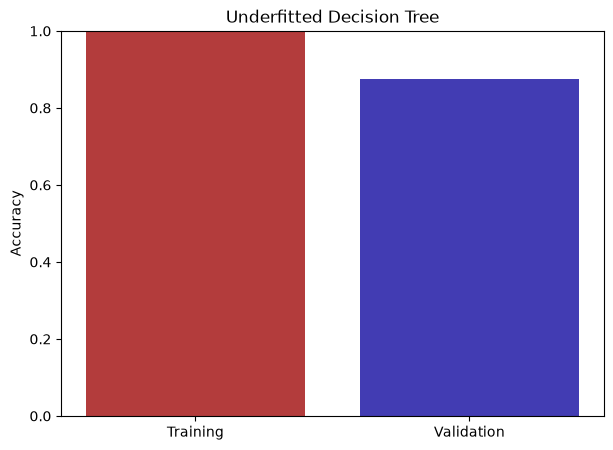

In [187]:
plt.figure(figsize=(7,5))
plt.bar(["Training","Validation"],[overfit_train_score,overfit_val_score],color=["#b33c3c","#423cb3"])
plt.ylim(0,1)
plt.ylabel("Accuracy")
plt.title("Overfitted Decision Tree")
plt.show()


### Code Explanation

- `plt.figure()` creates the figure and defines its size.
- `plt.bar()` creates one bar for training accuracy and another for validation accuracy.
- `plt.ylim(0, 1)` sets the accuracy range between 0 and 1.
- `plt.ylabel()` labels the y-axis.
- `plt.title()` gives the chart a descriptive title.
- `plt.show()` displays the chart.

### Why Is This Step Important?

The numerical scores tell us the size of the generalization gap.

The visualization makes the difference between training and validation performance easier to observe.

### Data-Driven Interpretation

The training bar represents performance on data the model has already seen.

The validation bar represents performance on unseen data.

If the training bar is considerably higher than the validation bar, the chart supports the diagnosis of overfitting.

This means that the model performs very well on the training data but does not generalize equally well to unseen examples.
<hr style="height: 5px; background-color: #b33c3c ; border: none;">

## 6. Experiment 2 — Creating Underfitting

### Purpose

**What happens when the Decision Tree becomes too simple?**

The previous experiment showed what happens when the model is allowed to become highly complex.

I will intentionally increase the model complexity by removing the maximum depth restriction.

Now I will test the opposite situation.



In [188]:
underfit_model=DecisionTreeClassifier(max_depth=1,random_state=42)
underfit_model.fit(x_train,y_train)
underfit_train_score=underfit_model.score(x_train,y_train)
underfit_val_score=underfit_model.score(x_val,y_val)
print("Training Score: ",underfit_train_score)
test_score=underfit_model.score(x_test,y_test)
print("Validation Score: ",underfit_val_score)
underfit_gap=underfit_train_score-underfit_val_score
print("Gap: ",underfit_gap)

Training Score:  0.75
Validation Score:  0.75
Gap:  0.0



### Why Is This Step Important?

A model with very limited capacity may not be able to capture the important relationships in the dataset.

This gives us the opposite failure mode from overfitting.

Instead of learning too much from the training data, the model may fail to learn enough.

### Data-Driven Question

After training the simple tree, I will compare its training and validation scores.

If both scores are relatively low, this will provide evidence of underfitting.
<hr style="height: 5px; background-color: #b33c3c ; border: none;">

## 7. Comparing Underfitting, Baseline, and Overfitting

I now have three different model configurations:

1. A very simple tree.
2. A moderately constrained tree.
3. An unrestricted tree.

The question is:

> Can the training and validation scores clearly distinguish the three situations?

In [189]:
com = pd.DataFrame({
    "Model": [
        "Underfitted",
        "Baseline",
        "Overfitted"
    ],
    "Training Score": [
        underfit_train_score,
        model_train_score,
        overfit_train_score
    ],
    "Validation Score": [
        underfit_val_score,
        model_val_score,
        overfit_val_score
    ],
    "Train-Validation Gap": [
        underfit_gap,
        gap,
        overfit_gap
    ]
})

com

,Model,Training Score,Validation Score,Train-Validation Gap
0,Underfitted,0.750,0.750,0.000
1,Baseline,0.875,0.875,0.000
2,Overfitted,1.000,0.875,0.125


### What does the data tell us?

The comparison demonstrates the two different failure modes.

The underfitted model has limited learning capacity, so both scores are relatively low.

The overfitted model performs very well on the training data but loses performance on validation data.

The baseline lies between these two extremes.

This demonstrates the bias-variance trade-off:

- Too simple → high bias → underfitting.
- Too complex → high variance → overfitting.
- Appropriate complexity → better generalization.
<hr style="height: 5px; background-color: #b33c3c ; border: none;">

## 8. Experiment 3 — Fixing Overfitting

The unrestricted tree was too complex.

Instead of allowing the tree to grow freely, I will control its complexity using:

- `max_depth`
- `min_samples_leaf`

These parameters restrict how detailed the tree can become.

The question is:

> Can reducing model complexity shrink the train-validation gap?

In [190]:
fixed_model = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=3,
    random_state=42
)

fixed_model.fit(x_train, y_train)

fix_train_score = fixed_model.score(x_train, y_train)
fix_val_score = fixed_model.score(x_val, y_val)

fix_gap = fix_train_score - fix_val_score

print("Training Score:", fix_train_score)
print("Validation Score:", fix_val_score)
print("Train-Validation Gap:", fix_gap)

Training Score: 0.875
Validation Score: 0.875
Train-Validation Gap: 0.0


### Evaluating the Fix

The goal of the fix is not simply to reduce the training score.

The goal is to achieve better generalization.

I will therefore compare the new validation score and train-validation gap with the original overfitted model.

If the gap becomes smaller while validation performance remains strong, reducing model complexity helped control overfitting.
<hr style="height: 5px; background-color: #b33c3c ; border: none;">

## 9. Visualizing the Three Model Behaviors

A final visualization will summarize the behavior of the models.

I will compare training and validation accuracy across the underfitted, baseline, overfitted, and fixed models.

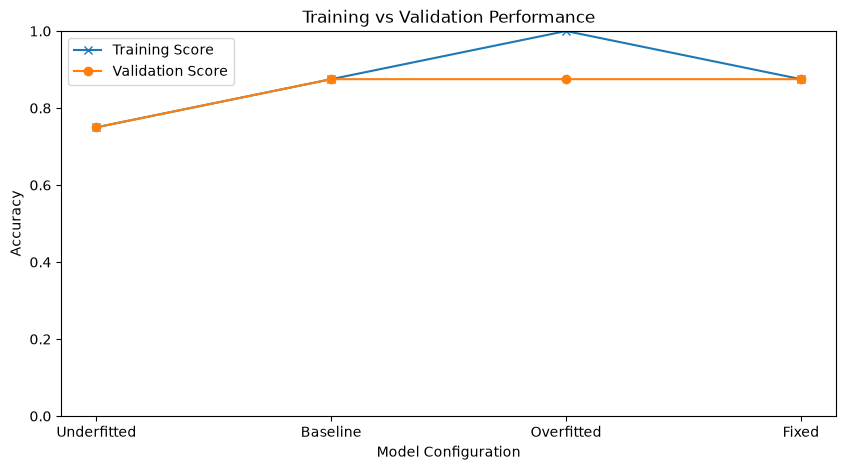

In [191]:
models = [
    "Underfitted",
    "Baseline",
    "Overfitted",
    "Fixed"
]

train_scores = [
    underfit_train_score,
    model_train_score,
    overfit_train_score,
    fix_train_score
]

val_scores = [
    underfit_val_score,
    model_val_score,
    overfit_val_score,
    fix_val_score
]

x = range(len(models))

plt.figure(figsize=(10, 5))

plt.plot(x, train_scores, marker="x", label="Training Score")
plt.plot(x, val_scores, marker="o", label="Validation Score")

plt.xticks(x, models)
plt.ylim(0, 1)

plt.xlabel("Model Configuration")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Performance")

plt.legend()
plt.show()

### Chart Interpretation

The plot shows how training and validation performance change across different model configurations.

The underfitted model demonstrates the low-capacity case.

The overfitted model demonstrates the high-capacity case, where training performance becomes much higher than validation performance.

The fixed model shows the effect of controlling model complexity.

The desired behavior is not necessarily the highest training score.

Instead, the goal is strong validation performance with a relatively small train-validation gap.

This is the practical meaning of balancing bias and variance.
<hr style="height: 5px; background-color: #b33c3c ; border: none;">

## 10. Regularization: Ridge and Lasso

Another important approach to controlling model complexity is regularization.

For linear regression models, two common regularization techniques are Ridge and Lasso.

### Ridge — L2 Regularization

Ridge adds a penalty based on the squared values of the model coefficients.

It encourages the coefficients to become smaller.

In [192]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)

### Lasso — L1 Regularization

Lasso adds a penalty based on the absolute values of the coefficients.

It can shrink some coefficients exactly to zero, which can effectively remove weak features.

In [193]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)

The alpha parameter controls the regularization strength.

A larger alpha means a stronger penalty and therefore a simpler model.

In this notebook, the actual classification experiment uses Decision Tree complexity controls because the target variable is categorical.

Ridge and Lasso are introduced here to understand the broader idea of regularization.



---

## 11. Conclusion

This practice experiment demonstrated how model complexity affects generalization.

The first experiment showed overfitting: the model became very strong on the training data but performed worse on validation data.

The second experiment showed underfitting: the model was too simple and therefore performed poorly on both training and validation data.

The third experiment showed that controlling model complexity can reduce overfitting.

The main diagnostic tool was the train-validation gap.

The key lesson is:

> A good machine learning model is not the model that memorizes the training data. It is the model that learns useful patterns and generalizes well to unseen data.